## MULTI-DIMENSIONAL FDA + $B$-SPLINES

#### 0. Initialisation:

##### 0.1. Load libraries:

In [110]:
#install.packages("fda")
#install.packages("hash")

In [111]:
library("caret")
library("e1071")
library("fda")
library("ggplot2")
library("psychTools")
library("readr")
library("splines")
library("tidymodels")
library("tidyverse")

##### 0.2. load data:

In [112]:
## MULTI-dim:
specie <- c("E", "G", "R")
files <- c("../../pipeline_2/data/pre_FDA_E_IGT.csv", "../../pipeline_2/data/pre_FDA_G_IGT.csv", "../../pipeline_2/data/pre_FDA_R_IGT.csv")

#### 1. Clean datasets:

In [113]:
## remove specific replicas that are too unstable => metals & unstable replicates or tests:
to_exclude <- c("2A10", "2A11", "Acide Acrylique1", "alphaEndosulfan2", "betaEndosulfan2", "Chlorpyrifos0", "Chlorpyrifos1", "Chlorothanolil2", "DDD(2-4)1", "Dieldrin0", "Dieldrin1", "Hydrazine0", "Hydrazine1", "Methomyl1", "Quinoxyfen1", "Trichlorobenzene(123)0", "Trichlorobenzene(123)1", "Trichlorobenzene(123)2", "Trichlorobenzene(123)3", "Trifluralin1")

In [114]:
data_spec <- lapply(files, function(file){
  df <- read.csv(file, row.names = "", check.names = FALSE)
  df[, to_exclude] <- list(NULL)
  return(df)
})

names(data_spec) <- specie

In [115]:
df_E1 <- rename(data_spec$E, Chlorothalonil0 = Chlorothanolil0)
df_E <- rename(df_E1, Chlorothalonil1 = Chlorothanolil1)

df_G1 <- rename(data_spec$G, Chlorothalonil0 = Chlorothanolil0)
df_G <- rename(df_G1, Chlorothalonil1 = Chlorothanolil1)

df_R1 <- rename(data_spec$R, Chlorothalonil0 = Chlorothanolil0)
df_R <- rename(df_R1, Chlorothalonil1 = Chlorothanolil1)

#### 2. Perform mFDA (3D):

Do FDA on all species (multi-species FDA).

In [116]:
grid_points <- 1:120

In [117]:
## first convert to a matrix (so that FDA can be done MULTI-dim way):
data_matrices <- lapply(specie, function(spec){
  as.matrix(data_spec[[spec]][grid_points, ])
})

names(data_matrices) <- specie

In [118]:
FDA <- lapply(specie, function(spec){
  Data2fd(argvals = grid_points, y = data_matrices[[spec]])
})

names(FDA) <- specie

In [119]:
data_matrices[['E']][, 20:40]

,Benzo(a)pyrene0,Benzo(a)pyrene1,betaEndosulfan0,betaEndosulfan1,Biphenyl0,Carbaryl0,Carbaryl1,Chlorothanolil0,Chlorothanolil1,Cypermethrine0,⋯,DDD(2-4)0,DDD(2-4)2,Dicofol0,Dicofol1,H400,H401,H402,Ibuprofen0,Isodrin0,Isodrin1
0,0.006730688,0.005275465,0.1409005,0.02391867,0.03795908,0,0.013021464,0.02575873,0.01997899,0.004492464,⋯,0.000000000,0.008648075,0.17609301,0.05475459,0.01439157,0.009402063,0.000000000,0.01354702,0.005819519,0.004704078
1,0.006916242,0.006858197,0.1377086,0.02700257,0.03526225,0,0.011587341,0.02415754,0.02567950,0.000000000,⋯,0.000000000,0.007866869,0.22536335,0.04735476,0.01438932,0.009999236,0.000000000,-0.00825328,0.000000000,0.004780166
2,0.006892896,0.008690659,0.1360658,0.03246792,0.03283197,0,0.010835310,0.02461765,0.03582409,0.000000000,⋯,0.000000000,0.006756738,0.26510708,0.04620376,0.01570767,0.010739165,0.000000000,-0.01128787,0.000000000,0.004554899
3,0.007246740,0.009888953,0.1330280,0.03727669,0.02998213,0,0.011822966,0.02527179,0.05232431,0.004205665,⋯,0.000000000,0.007068936,0.29530452,0.05973669,0.01764361,0.011950520,0.000000000,-0.01102098,0.000000000,0.000000000
4,0.007188762,0.011256647,0.1308949,0.04075217,0.02865607,0,0.013138756,0.02611147,0.07501086,0.004823577,⋯,0.000000000,0.006869887,0.36282691,0.07444647,0.01889536,0.015419522,0.000000000,0.01267085,0.000000000,0.000000000
5,0.007085816,0.013861893,0.1273952,0.04286386,0.02965166,0,0.012178769,0.04091863,0.11840443,0.005914346,⋯,0.000000000,0.007330477,0.38856170,0.07838395,0.01767578,0.020726243,0.000000000,0.01950235,0.000000000,0.000000000
6,0.006708769,0.015973317,0.1249649,0.04404216,0.03246732,0,0.011459416,0.08401681,0.17827241,0.007588178,⋯,0.000000000,0.008390418,0.40249242,0.08678064,0.01745059,0.025431784,0.000000000,0.01659427,0.000000000,0.000000000
7,0.006330125,0.018373664,0.1218021,0.04273825,0.03416039,0,0.010555819,0.13669609,0.26514837,0.008849465,⋯,0.000000000,0.011665386,0.40337183,0.08876962,0.03118074,0.031578830,0.000000000,0.01421495,0.000000000,0.004564324
8,0.006463861,0.019677428,0.1199829,0.04503568,0.03735212,0,0.010852628,0.20464092,0.36665184,0.010355571,⋯,0.000000000,0.020062277,0.38837206,0.08520775,0.05220542,0.036294633,0.000000000,0.01590756,0.000000000,0.007277801
9,0.005711027,0.019905388,0.1186490,0.04902531,0.04168824,0,0.010815207,0.28878589,0.48782379,0.011641222,⋯,0.000000000,0.025347416,0.36281808,0.08137258,0.05744496,0.036947372,0.000000000,0.01861587,0.000000000,0.008487069


In [120]:
## init parameters:
domain_range <- c(0, 120) ## related to knots
order <- 4 ## degree of approx used (here, cubic B-splines so 3) + 1 = 4
knots <- c(0, 10, 20, 30, 60, 90, 120) ## already set (ref. Ruck et al., 2025)
nb_basis <- (length(knots) + order - 2) ## nb of fcts to get, cannot be changed

In [121]:
## get smoothed fcts:
bbs <- create.bspline.basis(rangeval = domain_range, nbasis = nb_basis, norder = order, breaks = knots)

fdPar_obj <- fdPar(bbs, Lfdobj = 2, lambda = 1e-2)  # tune lambda via GCV
FDA_smooth_pen <- lapply(specie, function(spec){
  smooth.basis(argvals = grid_points, 
               y = data_matrices[[spec]], 
               fdParobj = fdPar_obj)$fd
})
names(FDA_smooth_pen) <- specie

In [122]:
## extract coefs:
coef_list <- lapply(specie, function(spec){
  t(FDA_smooth_pen[[spec]]$coefs)
})
names(coef_list) <- specie

full_list <- lapply(seq_along(specie), function(i){
  M <- coef_list[[specie[i]]]
  colnames(M) <- paste0("bspline_", seq_len(ncol(M)), "_", i)
  M
})
names(full_list) <- specie

all <- cbind(full_list[["E"]], full_list[["G"]], full_list[["R"]])
df_all <- as.data.frame(all)

apply(df_all, 2, sd)

bspline_1_1 bspline_2_1 bspline_3_1 bspline_4_1 bspline_5_1 bspline_6_1 
  0.1568662   0.2607065   0.3558218   0.2470929   0.4525684   0.3300653 
bspline_7_1 bspline_8_1 bspline_9_1 bspline_1_2 bspline_2_2 bspline_3_2 
  0.4569444   0.3438221   0.3765282   0.2181744   0.4882494   0.4427074 
bspline_4_2 bspline_5_2 bspline_6_2 bspline_7_2 bspline_8_2 bspline_9_2 
  0.4963734   0.4511958   0.4407609   0.5566311   0.4121005   0.4441788 
bspline_1_3 bspline_2_3 bspline_3_3 bspline_4_3 bspline_5_3 bspline_6_3 
  0.1181651   0.1736542   0.1618929   0.3003719   0.2414643   0.3151790 
bspline_7_3 bspline_8_3 bspline_9_3 
  0.3289310   0.3010801   0.2887993

In [123]:
rownames(df_all)[rownames(df_all) == "Chlorothanolil0"] <- "Chlorothalonil0"
rownames(df_all)[rownames(df_all) == "Chlorothanolil1"] <- "Chlorothalonil1"
rownames(df_all)[rownames(df_all) == "Chlorothanolil2"] <- "Chlorothalonil2"

In [124]:
df_all[20:40, ]

,bspline_1_1,bspline_2_1,bspline_3_1,bspline_4_1,bspline_5_1,bspline_6_1,bspline_7_1,bspline_8_1,bspline_9_1,bspline_1_2,⋯,bspline_9_2,bspline_1_3,bspline_2_3,bspline_3_3,bspline_4_3,bspline_5_3,bspline_6_3,bspline_7_3,bspline_8_3,bspline_9_3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Benzo(a)pyrene0,0.0062563039,0.0079999960,0.005179795,0.007522558,0.0072171457,-0.0050593643,0.009829778,0.007262788,0.006734922,0.0207521396,⋯,0.031451095,-0.033352493,0.052600428,-0.068872753,0.053044670,0.633069865,-0.163775910,0.102830151,-5.600361e-02,0.0198793686
Benzo(a)pyrene1,0.0011393776,0.0116848390,0.022964238,0.006838784,-0.0041600649,0.0036512054,0.014898163,0.009501057,-0.001458567,0.0137113571,⋯,0.066332797,-0.041226797,0.068239078,-0.104586115,0.137083294,0.022334797,0.049933513,0.002618508,6.511386e-02,-0.0307773449
betaEndosulfan0,0.1413728947,0.1457643275,0.062902699,0.315718645,0.6843853710,-0.1425877237,0.199650635,-0.007348187,0.080224961,-0.0009664508,⋯,-0.001019957,0.003435648,-0.005507073,0.007653527,-0.007792003,0.008261671,0.034106105,-0.446873217,-2.352636e-01,-0.3052834364
betaEndosulfan1,-0.0494857894,0.1573128534,-0.169067892,0.483401109,0.3484145768,0.1003224789,-0.029295449,0.129745241,-0.004033799,0.0189826624,⋯,0.106467899,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000e+00,0.0000000000
Biphenyl0,0.0566832110,0.0018694659,0.068469917,0.037077626,0.0313608061,-0.0208829117,0.066309868,-0.013399282,0.033066459,0.0825990393,⋯,0.009418177,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000e+00,0.0000000000
Carbaryl0,-0.0040301059,0.0064913954,-0.009167424,0.009832874,-0.0171281779,0.0003299394,0.002350795,-0.004060346,0.009220817,0.0095357944,⋯,0.048814816,0.475123033,0.479616663,0.246416738,0.325778811,0.031035271,-0.029959001,0.017724744,4.111355e-02,-0.0185326065
Carbaryl1,0.0102989871,0.0154930753,0.005731071,0.018217443,-0.0091704863,0.0300679229,0.004791708,-0.005439549,0.007877847,-0.0027265765,⋯,0.049711144,0.108024290,-0.174058572,0.243917880,-0.231202781,0.060672850,-0.060314034,0.056081796,-5.230944e-02,0.1086602791
Chlorothalonil0,0.3190079900,-0.4811450592,0.795927970,0.375057288,-0.1636329692,0.1033441346,-0.101152200,0.079664016,-0.027991141,0.0054955342,⋯,-0.004888579,-0.005983194,-0.002220180,0.064328003,-0.346362780,0.093867505,0.046097402,-0.172463186,2.865780e-01,-0.4393316530
Chlorothalonil1,-0.0498051964,0.0504892546,0.422756169,0.282702347,0.4907750068,0.3588281681,-0.278466293,-0.227038333,-0.129586745,0.3320923657,⋯,-0.111302239,-0.013502750,0.013878963,0.095246374,-0.044244914,0.258867534,0.085957903,0.376486707,1.633197e-01,0.0982278962


In [125]:
write.csv(df_all, "../../pipeline_2/data/multispec_bsplines_IGT.csv")
write.csv(df_all, "../data/multispec_bsplines_IGT.csv")

#### A.1: UNI-dimensional visualisations:

In [126]:
## UNI-dim:
df_E <- read.csv("../../pipeline_2/data/pre_FDA_E_IGT.csv", row.names = "", check.names = FALSE)
df_G <- read.csv("../../pipeline_2/data/pre_FDA_G_IGT.csv", row.names = "", check.names = FALSE)
df_R <- read.csv("../../pipeline_2/data/pre_FDA_R_IGT.csv", row.names = "", check.names = FALSE)

In [127]:
df_R_120[, 71:83]

,Tetrachloroethylene1,Trichlorobenzene(123)0,Trichlorobenzene(123)1,Trichlorobenzene(123)3,Trichloroethylene0,Trichloroethylene1,Trichloroethylene2,Trifluralin0,Trifluralin1,Trifluralin2,Trifluralin3,Verapamil0,Verapamil1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0.5345379,0.8839889,0.4960864,0.5689488,0.7768409,0.6642125,0.6549019,0.8958208,0.9733312,0.8299427,0.6550614,0.5497480,0.4652219
1,0.5728051,0.8905828,0.4705891,0.5877062,0.7515452,0.6831273,0.6327839,0.8927443,0.9750256,0.7978746,0.6768413,0.5620936,0.4558487
2,0.6004399,0.8955612,0.4495636,0.6145276,0.7239179,0.7040292,0.6108827,0.8854924,0.9710857,0.7748112,0.6961937,0.5741694,0.4492522
3,0.6200324,0.8952674,0.4450384,0.6408359,0.6936822,0.7274502,0.5926969,0.8771461,0.9598553,0.7603171,0.7117595,0.5866540,0.4416244
4,0.6295075,0.8897383,0.4595690,0.6678681,0.6571687,0.7402124,0.5763511,0.8689420,0.9423146,0.7579396,0.7203140,0.5973620,0.4363335
5,0.6276963,0.8781970,0.4772410,0.6906478,0.6182853,0.7429098,0.5612607,0.8612998,0.9211959,0.7722783,0.7281036,0.6050208,0.4334054
6,0.6141956,0.8669582,0.4968737,0.7090630,0.5798589,0.7348704,0.5516207,0.8528431,0.8932667,0.7946771,0.7296645,0.6151567,0.4284789
7,0.5939790,0.8492642,0.5105614,0.7163581,0.5476198,0.7167415,0.5402005,0.8513047,0.8592323,0.8264451,0.7276619,0.6266436,0.4228852
8,0.5743217,0.8283409,0.5165393,0.7181537,0.5151501,0.6936723,0.5243339,0.8581648,0.8209645,0.8639382,0.7212341,0.6419514,0.4167599


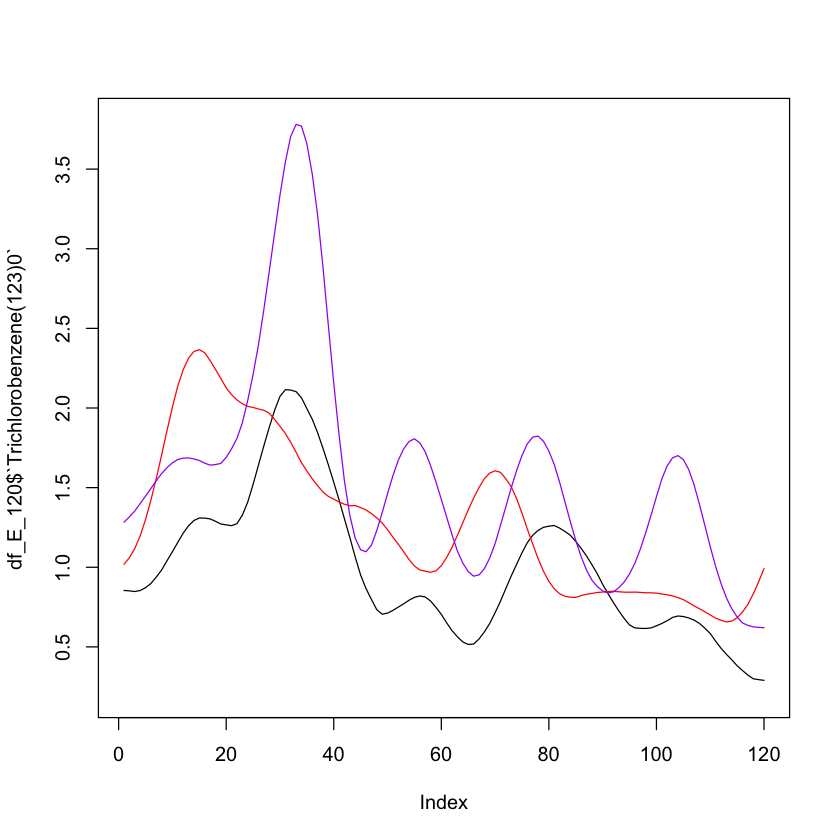

In [128]:
plot(df_E_120$`Trichlorobenzene(123)0`, type = "l", ylim = c(0.2, 3.8))
lines(df_E_120$`Trichlorobenzene(123)1`, col = "red")
lines(df_E_120$`Trichlorobenzene(123)3`, col = "purple")

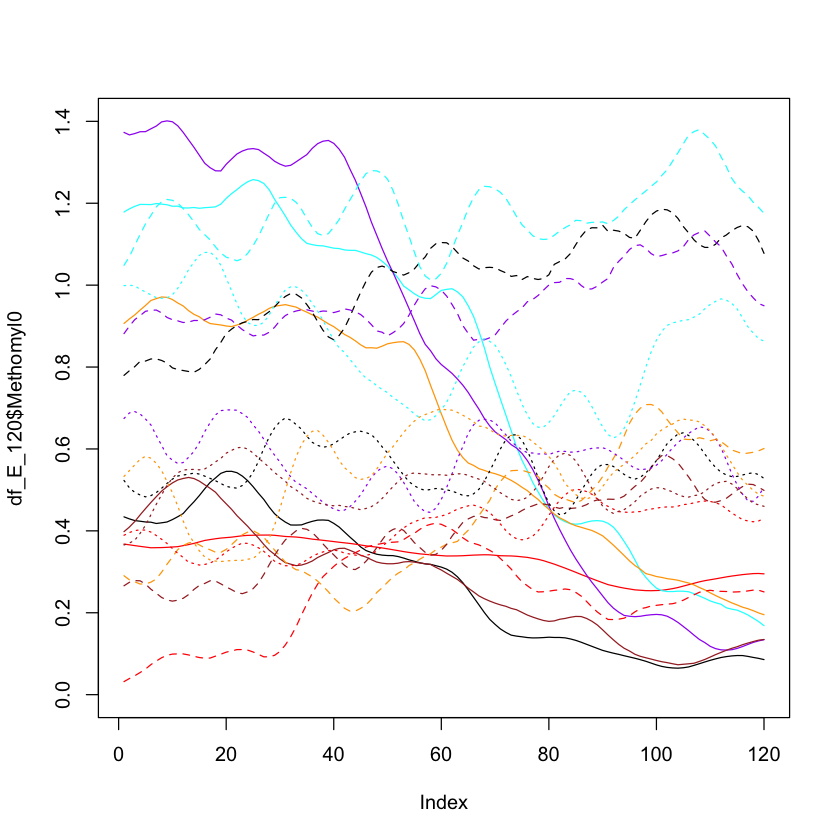

In [129]:
plot(df_E_120$Methomyl0, type = "l", ylim = c(0, 1.4))
lines(df_E_120$Methomyl1, col = "red")
lines(df_E_120$Methomyl2, col = "cyan")
lines(df_E_120$Methomyl3, col = "purple")
lines(df_E_120$Methomyl4, col = "green")
lines(df_E_120$Methomyl5, col = "orange")
lines(df_E_120$Methomyl6, col = "brown")
lines(df_G_120$Methomyl0, col = "black", lty = "dashed")
lines(df_G_120$Methomyl1, col = "red", lty = "dashed")
lines(df_G_120$Methomyl2, col = "cyan", lty = "dashed")
lines(df_G_120$Methomyl3, col = "purple", lty = "dashed")
lines(df_G_120$Methomyl4, col = "green", lty = "dashed")
lines(df_G_120$Methomyl5, col = "orange", lty = "dashed")
lines(df_G_120$Methomyl6, col = "brown", lty = "dashed")
lines(df_R_120$Methomyl0, col = "black", lty = "dotted")
lines(df_R_120$Methomyl1, col = "red", lty = "dotted")
lines(df_R_120$Methomyl2, col = "cyan", lty = "dotted")
lines(df_R_120$Methomyl3, col = "purple", lty = "dotted")
lines(df_R_120$Methomyl4, col = "green", lty = "dotted")
lines(df_R_120$Methomyl5, col = "orange", lty = "dotted")
lines(df_R_120$Methomyl6, col = "brown", lty = "dotted")

In [130]:
process_df <- function(df, species_label) {
  df %>%
    mutate(time = row_number()) %>%
    pivot_longer(
      cols = starts_with("Methomyl"),
      names_to = "replicate",
      values_to = "value"
    ) %>%
    mutate(species = species_label)
}

df_long <- bind_rows(
  process_df(df_E, "Erpobdella"),
  process_df(df_G, "Gammarus"),
  process_df(df_R, "Radix")
)

## median trajectory per species (across the 7 replicates):
df_median <- df_long %>%
  group_by(species, time) %>%
  summarise(median_value = median(value, na.rm = TRUE), .groups = "drop") %>%
  mutate(legend_label = paste0(species, " (médiane)"))

legend_colors <- c(
  "Réplicats" = "grey70",
  "Erpobdella (médiane)" = "#1b9e77",
  "Gammarus (médiane)" = "#d95f02",
  "Radix (médiane)" = "#7570b3"
)

png('../plots/replicates_methomyl.png', width = 3200, height = 2400, res = 400)
ggplot() +
  geom_line(
    data = df_long,
    aes(x = time, y = value, group = replicate, color = "Réplicats"),
    linewidth = 0.4, alpha = 0.8
  ) +
  geom_line(
    data = df_median,
    aes(x = time, y = median_value, color = legend_label),
    linewidth = 1
  ) +
  scale_color_manual(name = "Légende:", values = legend_colors) +
  facet_wrap(~ species, ncol = 1, scales = "free_y") +
  labs(
    x = "Temps",
    y = "Comportement (Méthomyl)",
    title = "Réplicats de méthomyl par espèce"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")
dev.off()

agg_record_40445e7ad761 
                      2

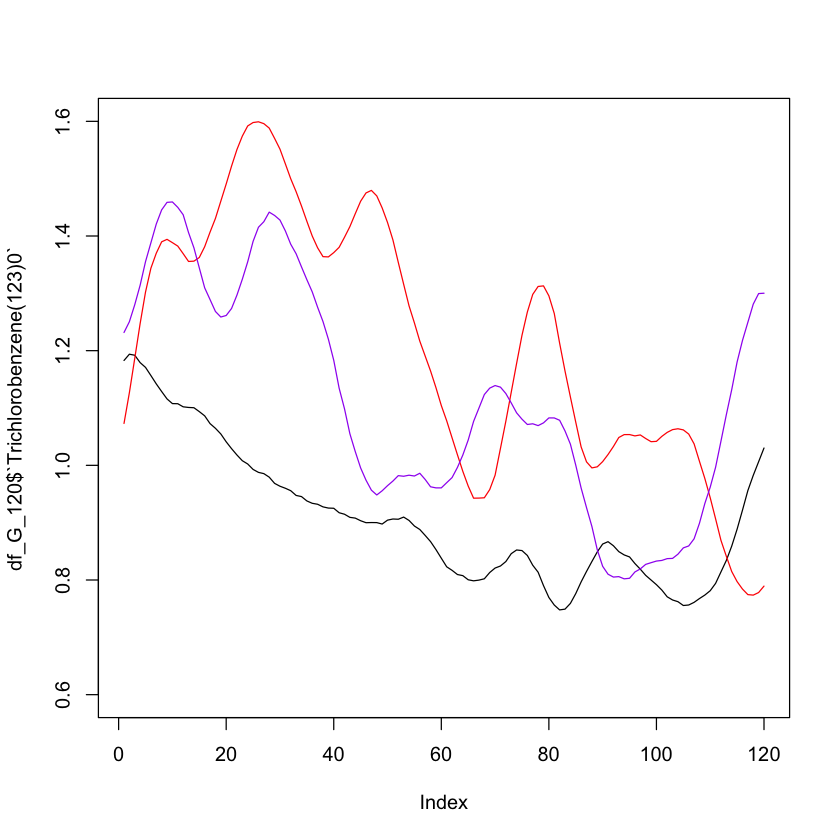

In [131]:
plot(df_G_120$`Trichlorobenzene(123)0`, type = "l", ylim = c(0.6, 1.6))
lines(df_G_120$`Trichlorobenzene(123)1`, col = "red")
lines(df_G_120$`Trichlorobenzene(123)3`, col = "purple")

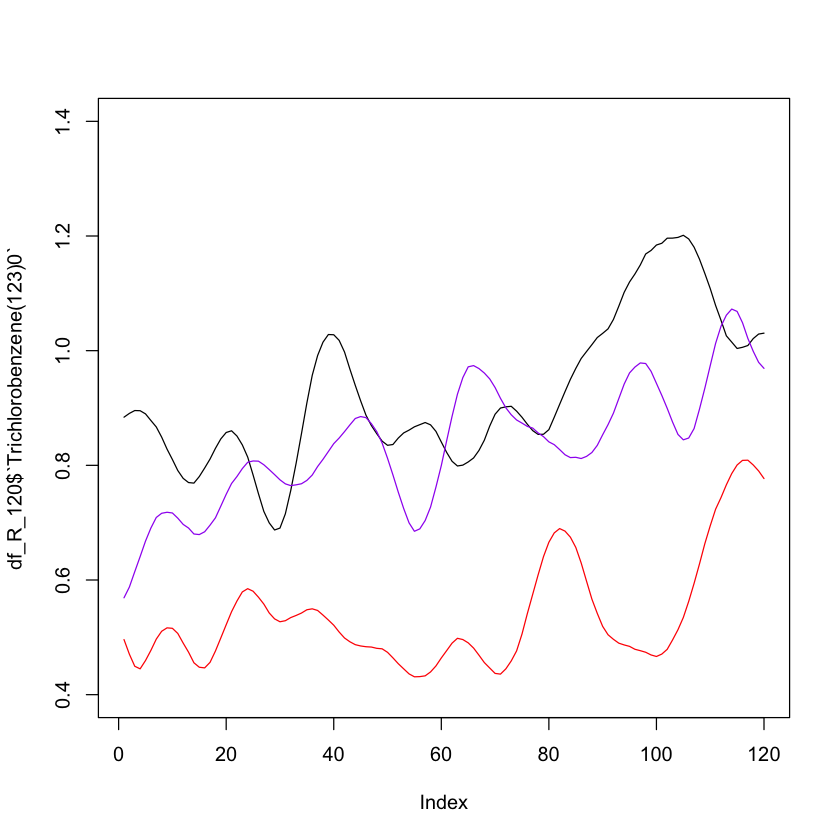

In [132]:
plot(df_R_120$`Trichlorobenzene(123)0`, type = "l", ylim = c(0.4, 1.4))
lines(df_R_120$`Trichlorobenzene(123)1`, col = "red")
lines(df_R_120$`Trichlorobenzene(123)3`, col = "purple")